<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS1_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv('/content/bank-full.csv')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16811 entries, 0 to 16810
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             16811 non-null  int64  
 1   job             16811 non-null  object 
 2   marital         16811 non-null  object 
 3   education       16811 non-null  object 
 4   default         16811 non-null  object 
 5   housing         16811 non-null  object 
 6   loan            16811 non-null  object 
 7   contact         16811 non-null  object 
 8   month           16811 non-null  object 
 9   day_of_week     16811 non-null  object 
 10  duration        16811 non-null  int64  
 11  campaign        16811 non-null  int64  
 12  pdays           16811 non-null  int64  
 13  previous        16811 non-null  int64  
 14  poutcome        16811 non-null  object 
 15  emp.var.rate    16811 non-null  float64
 16  cons.price.idx  16811 non-null  float64
 17  cons.conf.idx   16811 non-null 

## Visualisation

<Axes: xlabel='age', ylabel='Count'>

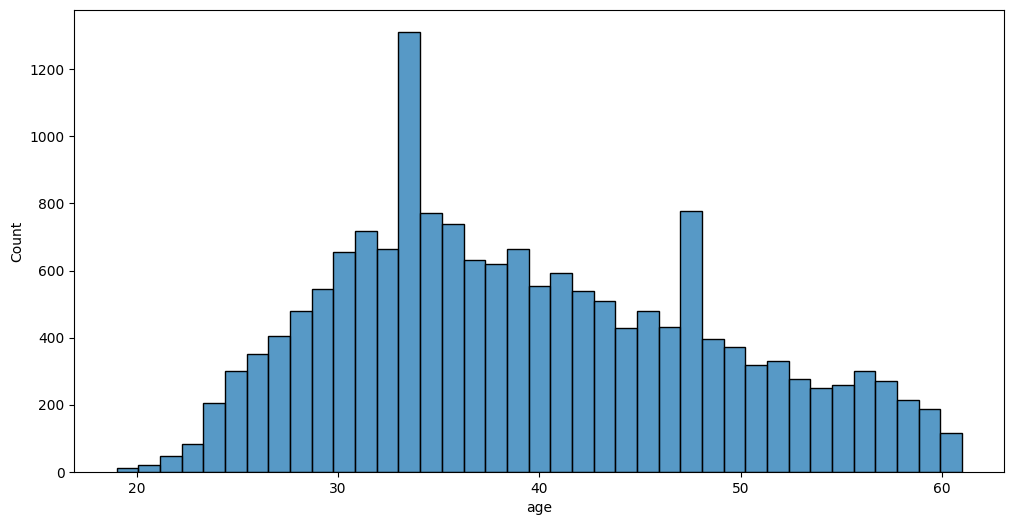

In [6]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='age')

<Axes: xlabel='age', ylabel='Count'>

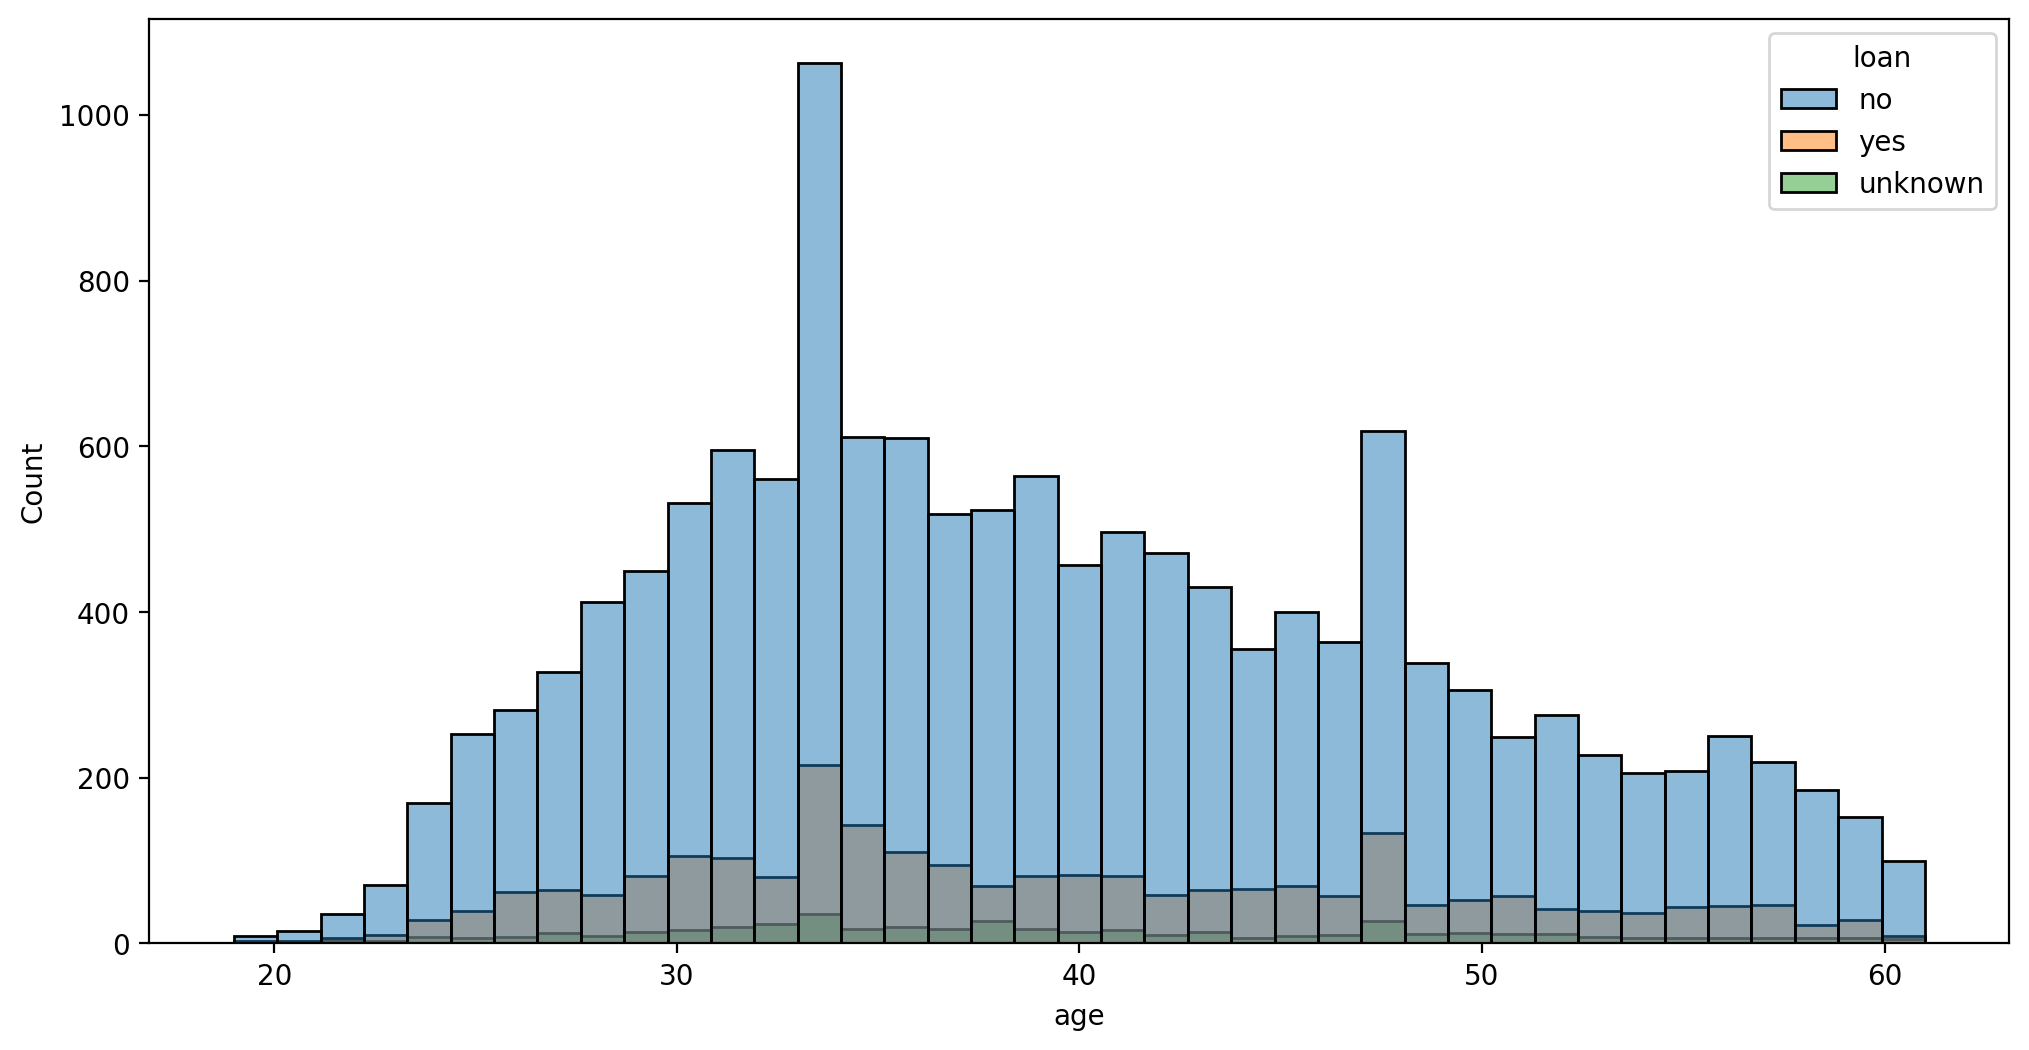

In [7]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df, x='age',hue='loan')

<Axes: xlabel='pdays', ylabel='Count'>

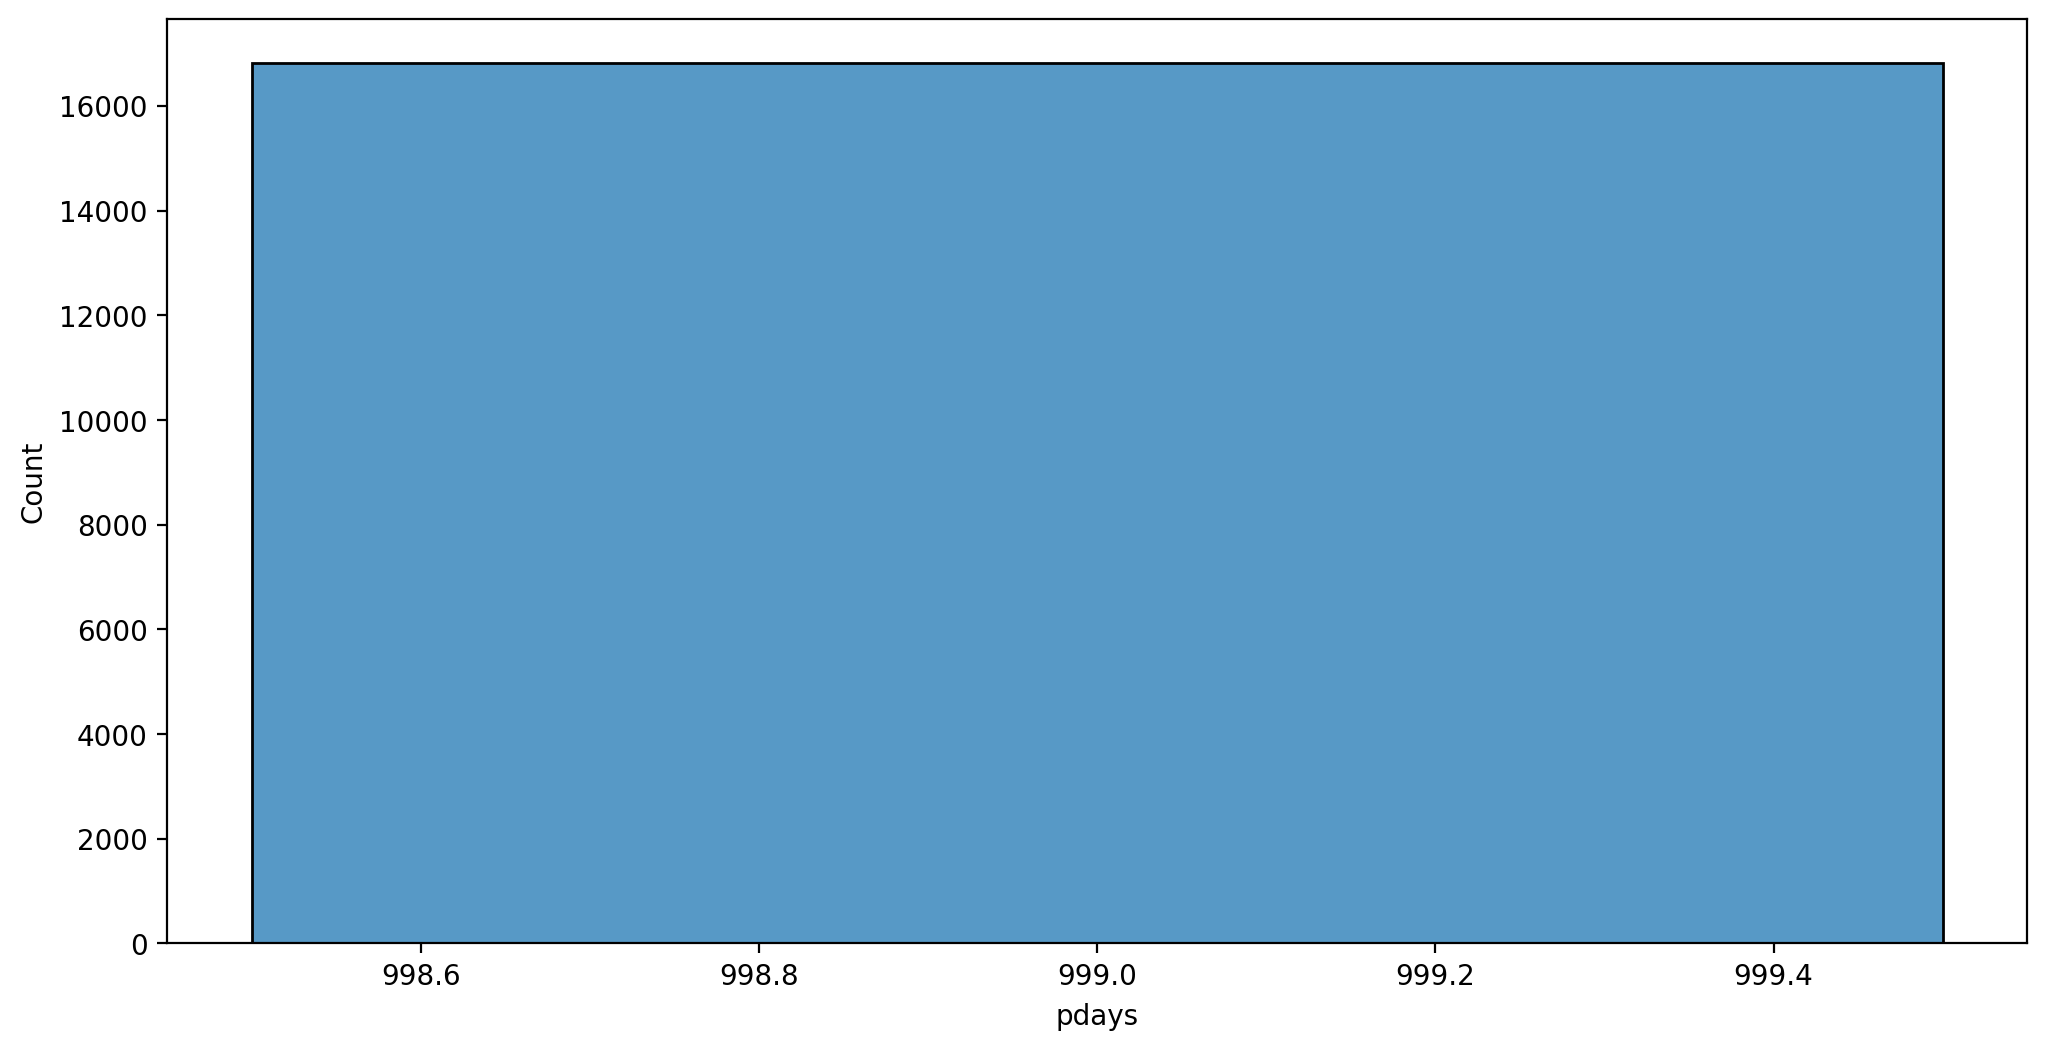

In [8]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df, x='pdays')

In [9]:
df['pdays'].unique()

array([999])

<Axes: xlabel='pdays', ylabel='Count'>

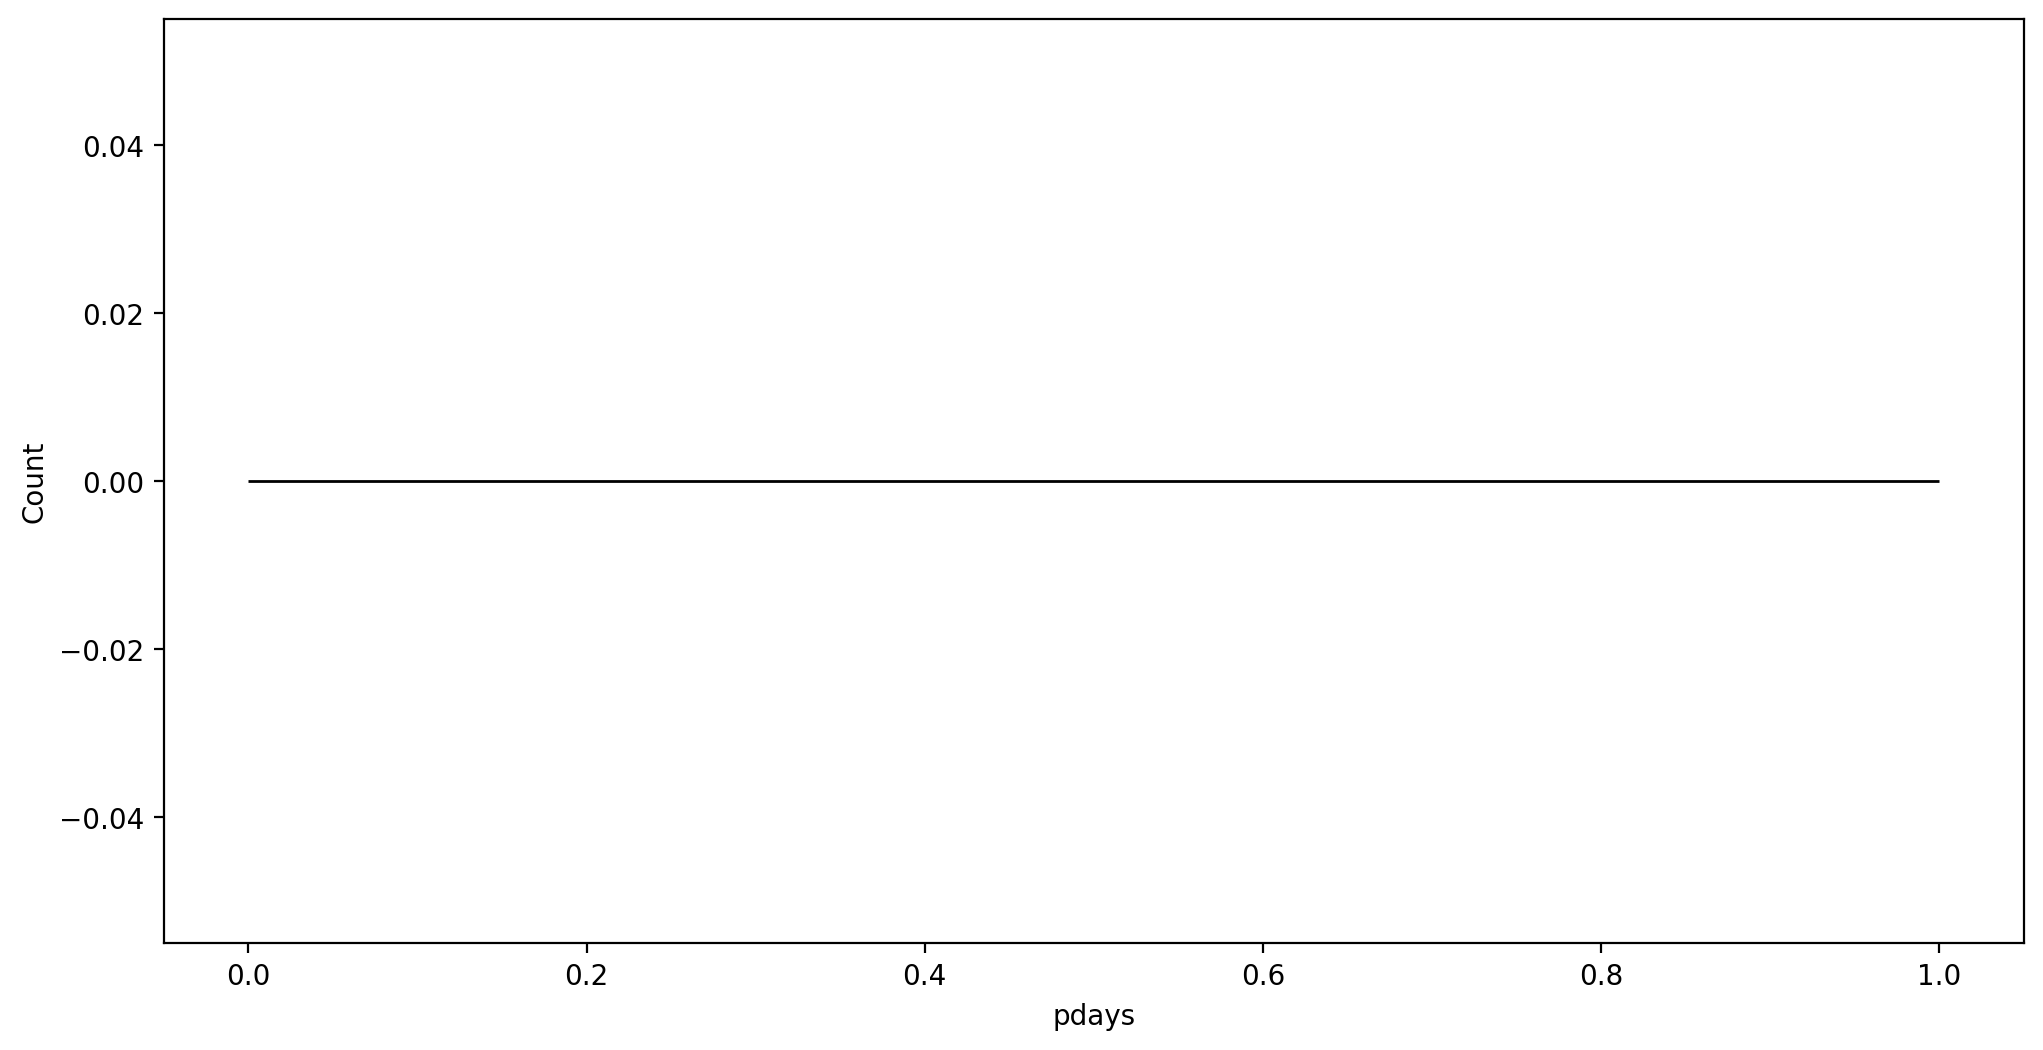

In [10]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df[df['pdays']!=999] , x='pdays')

(0.0, 2000.0)

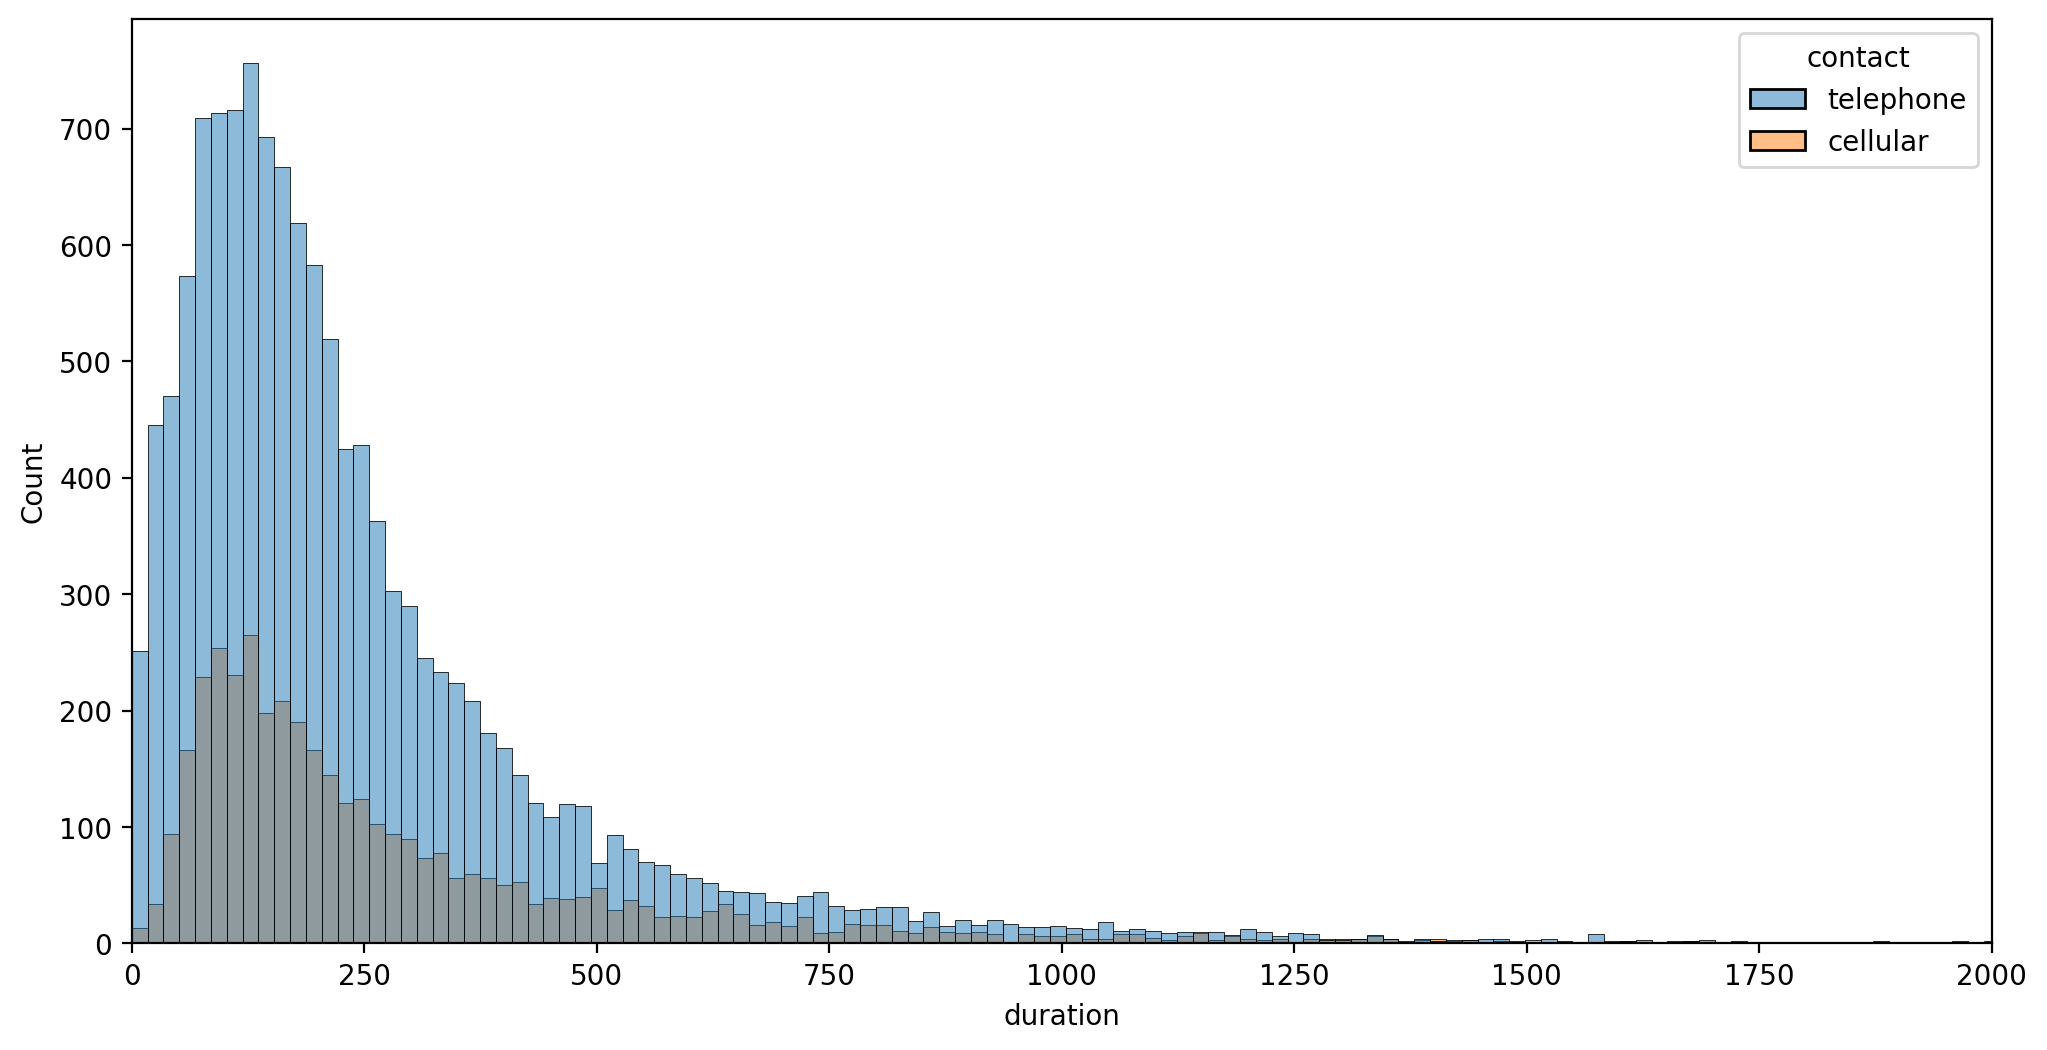

In [11]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df , x='duration',hue='contact')
plt.xlim(0,2000)

<Axes: xlabel='previous', ylabel='Count'>

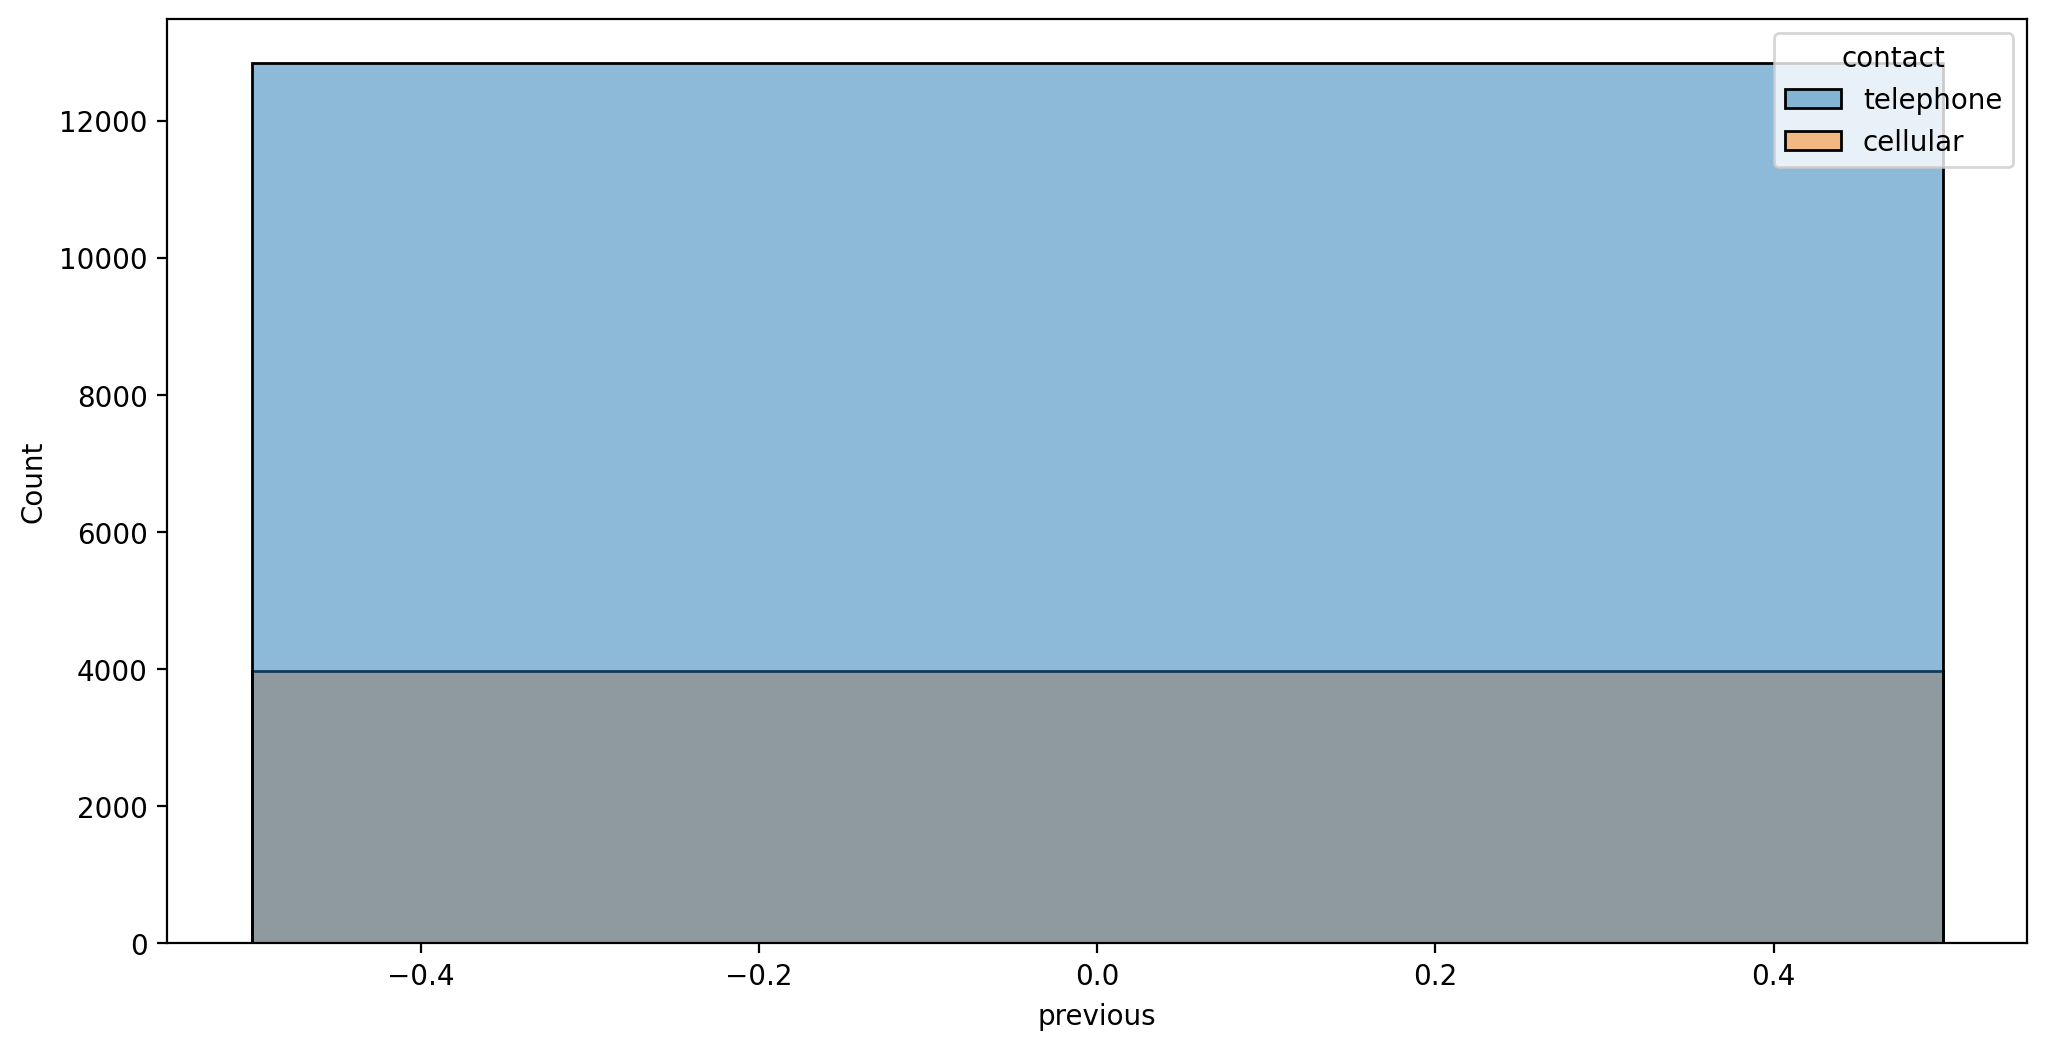

In [12]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df , x='previous',hue='contact')
# plt.xlim(0,2000)

<Axes: xlabel='contact', ylabel='count'>

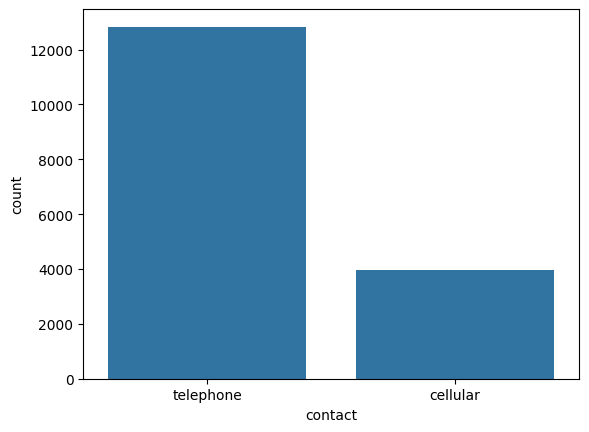

In [13]:
sns.countplot(data=df,x='contact')

In [14]:
X = df.drop('subscribed',axis=1)

In [15]:
X

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16806,57,self-employed,married,university.degree,no,no,no,cellular,jul,thu,313,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
16807,56,services,married,high.school,unknown,yes,no,telephone,jul,thu,279,11,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
16808,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,335,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1
16809,33,technician,single,high.school,no,yes,no,cellular,jul,thu,209,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1


In [16]:
X = pd.get_dummies(X,drop_first=True)

In [17]:
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,housing_yes,loan_unknown,loan_yes,contact_telephone,month_jun,month_may,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,True,True,False,False,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,True,True,False,False,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,True,False,True,True,False,False,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,False,True,False,True,True,False,False,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,False,True,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16806,57,313,1,999,0,1.4,93.918,-42.7,4.962,5228.1,...,False,False,False,False,False,False,False,True,False,False
16807,56,279,11,999,0,1.4,93.918,-42.7,4.962,5228.1,...,True,False,False,True,False,False,False,True,False,False
16808,47,335,2,999,0,1.4,93.918,-42.7,4.962,5228.1,...,True,False,False,False,False,False,False,True,False,False
16809,33,209,1,999,0,1.4,93.918,-42.7,4.962,5228.1,...,True,False,False,False,False,False,False,True,False,False


In [18]:
print(X.shape)

(16811, 43)


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
X_scaled = scaler.fit_transform(X)

In [22]:
X_scaled

array([[ 1.79569727, -0.01148922, -0.56905593, ..., -0.46653938,
        -0.51323971, -0.51573625],
       [ 1.9040697 , -0.44199059, -0.56905593, ..., -0.46653938,
        -0.51323971, -0.51573625],
       [-0.26337899, -0.14602089, -0.56905593, ..., -0.46653938,
        -0.51323971, -0.51573625],
       ...,
       [ 0.82034536,  0.27294919, -0.25086537, ...,  2.1434418 ,
        -0.51323971, -0.51573625],
       [-0.69686873, -0.21136485, -0.56905593, ...,  2.1434418 ,
        -0.51323971, -0.51573625],
       [ 1.79569727,  1.96420457, -0.56905593, ...,  2.1434418 ,
        -0.51323971, -0.51573625]])

In [23]:
inertia = []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

model.fit(X_scaled)

inertia.append(model.inertia_)

In [24]:
## n_init = Run K means 10 times with different starting centroid and keept the result

In [25]:
inertia

[463776.9566945995]

In [26]:
clusters = model.fit_predict(X_scaled)

In [27]:
clusters.shape

(16811,)

In [28]:
clusters

array([3, 0, 0, ..., 9, 1, 9], dtype=int32)

In [29]:
df['Clusters'] = clusters

In [30]:
df['Clusters'].value_counts()

,count
Clusters,
7,3054
3,3051
9,2934
0,1947
5,1612
1,1593
6,1140
2,869
8,462


In [31]:
df.groupby('Clusters').mean(numeric_only=True)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
Clusters,,,,,,,,,,
0,38.384181,264.154597,2.451977,999.0,0.0,1.100000,93.994000,-36.400000,4.857617,5191.000000
1,31.649718,287.856246,2.817954,999.0,0.0,1.400000,93.918000,-42.700000,4.960691,5228.100000
2,40.377445,259.377445,2.433832,999.0,0.0,1.100000,93.994000,-36.400000,4.857591,5191.000000
3,41.738774,268.521796,2.471321,999.0,0.0,1.100000,93.994000,-36.400000,4.857701,5191.000000
4,28.684564,316.221477,2.590604,999.0,0.0,1.267114,94.083826,-39.691946,4.908087,5211.666443
5,40.309553,264.208437,2.697891,999.0,0.0,1.100000,93.994000,-36.400000,4.857681,5191.000000
6,36.171053,250.594737,3.226316,999.0,0.0,1.400000,94.465000,-41.800000,4.931553,5228.100000
7,41.951539,234.721676,3.425999,999.0,0.0,1.400000,94.465000,-41.800000,4.931350,5228.100000
8,39.673160,228.298701,2.744589,999.0,0.0,1.258442,94.124355,-39.446753,4.905247,5210.593939


In [32]:
df.groupby('Clusters')['job'].value_counts()

Clusters  job          
0         services         786
          admin.           603
          blue-collar      167
          technician       105
          management        60
                          ... 
9         housemaid        121
          retired          105
          self-employed     90
          unemployed        64
          unknown           10
Name: count, Length: 99, dtype: int64

In [33]:
df.groupby('Clusters')['marital'].value_counts()


Clusters  marital 
0         married     1191
          single       490
          divorced     264
          unknown        2
1         single      1511
          divorced      79
          unknown        3
2         married      601
          single       166
          divorced     100
          unknown        2
3         married     2333
          single       428
          divorced     288
          unknown        2
4         single       137
          married       11
          divorced       1
5         married      925
          single       469
          divorced     209
          unknown        9
6         single       887
          divorced     244
          unknown        9
7         married     2815
          divorced     239
8         married      283
          single       128
          divorced      51
9         married     2465
          divorced     466
          unknown        3
Name: count, dtype: int64

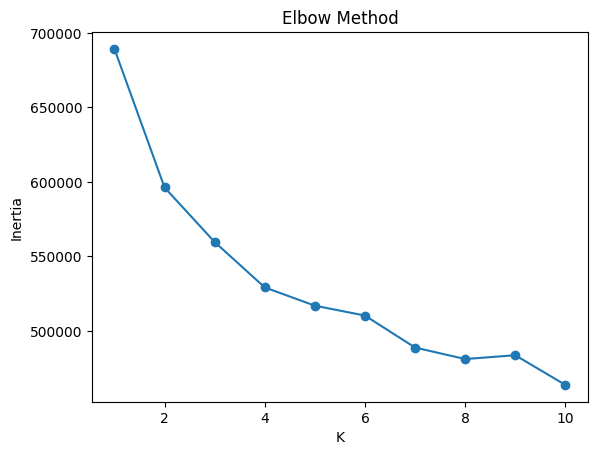

In [38]:
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, len(inertia) + 1), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [67]:
optimal_k = 3
final_model = KMeans(n_clusters=optimal_k,random_state=42,n_init =10)
df['Clusters'] = final_model.fit_predict(X_scaled)

In [68]:
df['Clusters'].value_counts()

,count
Clusters,
1,7763
2,4674
0,4374


In [69]:
df.groupby('Clusters').mean(numeric_only=True)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
Clusters,,,,,,,,,,
0,40.279607,238.793324,3.357339,999.0,0.0,1.4,94.465,-41.8,4.931639,5228.1
1,40.327580,265.111297,2.512560,999.0,0.0,1.1,93.994,-36.4,4.857663,5191.0
2,37.145272,285.703680,2.714163,999.0,0.0,1.4,93.918,-42.7,4.960773,5228.1


In [70]:
df.groupby('Clusters')['job'].value_counts()


Clusters  job          
0         blue-collar      1309
          admin.            921
          technician        596
          services          474
          management        275
          entrepreneur      193
          self-employed     163
          retired           123
          unemployed        120
          housemaid         117
          unknown            47
          student            36
1         blue-collar      2295
          admin.           1601
          technician       1060
          services          932
          management        553
          entrepreneur      289
          self-employed     253
          housemaid         229
          retired           215
          unemployed        171
          unknown            99
          student            66
2         blue-collar      1423
          admin.           1083
          technician        633
          services          531
          management        254
          entrepreneur      203
          housemaid         142
          self-employed     125
          retired           123
          unemployed         92
          student            47
          unknown            18
Name: count, dtype: int64

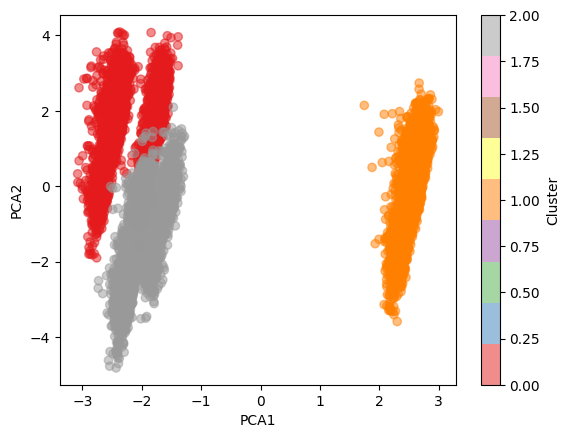

In [71]:
# Data is high Dimentional , to visualise it , reduce the features into 2D

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)

x_pca = pca.fit_transform(X_scaled)


plt.scatter(x_pca[:,0],x_pca[:,1],c=df['Clusters'],cmap='Set1',alpha=0.5)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Cluster')
plt.show()

In [72]:
cluster_labels = {
    0:'Young Low earning workers',
    1:'High Balace retired',
    2:"Mid aged Married Professinals"
}

df['Segement'] = df['Clusters'].map(cluster_labels)

In [73]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed,Clusters,Segement
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,High Balace retired
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,High Balace retired
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,High Balace retired
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,High Balace retired
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1,High Balace retired


In [49]:
df['Segement'].unique()

array(['High Balace retired', 'Young Low earning workers',
       'Mid aged Married Professinals'], dtype=object)